# I modelli yolo

## YOLO (You Only Look Once)

YOLO è l'architettura di riferimento per l'**object detection in tempo reale**. A differenza dei modelli precedenti che analizzavano l'immagine in più fasi (proposta di regioni e poi classificazione), YOLO tratta il rilevamento come un singolo problema di **regressione**, passando dai pixel dell'immagine alle coordinate delle scatole (bounding box) e alle probabilità delle classi in un unico passaggio della rete neurale.

---

### Il Meccanismo della Griglia

Il modello divide l'immagine in una griglia di celle (es. $13 \times 13$ o $26 \times 26$).

* Ogni cella è responsabile della previsione degli oggetti il cui centro cade all'interno della cella stessa.
* Per ogni cella, il modello prevede:
1. **Coordinate delle Bounding Box** ($x, y, w, h$).
2. **Punteggio di Confidenza**: quanto il modello è sicuro che ci sia un oggetto.
3. **Probabilità della Classe**: di quale oggetto si tratta (es. cane, auto, persona).



---

### Architettura del Modello

I modelli YOLO (dalle versioni storiche fino a YOLOv8, v10 o v11) sono generalmente composti da tre parti:

* **Backbone:** Una rete neurale convoluzionale (CNN) che estrae le caratteristiche (feature) dall'immagine (es. bordi, forme, texture).
* **Neck:** Collega il backbone alla testa del modello, mescolando e combinando le caratteristiche a diverse scale per rilevare oggetti di varie dimensioni.
* **Head:** La parte finale che effettua le previsioni effettive su classi e coordinate.

---

### Logica del Fine-Tuning

Il fine-tuning su YOLO permette di adattare un modello pre-addestrato (che sa già "vedere" forme generiche) a un compito specifico.

* **Transfer Learning:** Si mantengono i pesi del *Backbone* (congelandoli o usando un learning rate molto basso) poiché le caratteristiche visive di base sono universali.
* **Adattamento della Head:** Si modifica l'ultimo livello per corrispondere al numero di classi del nuovo dataset.
* **Loss Function:** Il modello viene ottimizzato calcolando l'errore tra le coordinate previste e quelle reali (Ground Truth) utilizzando una funzione di perdita complessa che combina errore di localizzazione e di classificazione:

$$\mathcal{L} = \lambda_{coord} \sum \text{err}_{pos} + \sum \text{err}_{conf} + \sum \text{err}_{cls}$$



### Vantaggi Principali

* **Velocità:** Estremamente rapido, capace di elaborare video a 60+ FPS.
* **Visione Globale:** Poiché guarda l'intera immagine durante l'addestramento, codifica meglio le informazioni contestuali sulle classi e sul loro aspetto.
* **Generalizzazione:** Apprende rappresentazioni degli oggetti molto robuste che si adattano bene a nuovi domini durante il fine-tuning.

In [1]:
import cv2
from ultralytics import YOLO

# 1. Carichiamo il modello (yolo11n è leggero e veloce per la webcam)
model = YOLO('yolo11n.pt') 

# 2. Apriamo la connessione con la webcam (0 è la camera predefinita)
cap = cv2.VideoCapture(0)

print("Premi 'q' per uscire...")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # 3. Eseguiamo l'inferenza sul singolo frame
    # stream=True rende l'elaborazione più efficiente per i video
    results = model(frame, stream=True)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Estraiamo le coordinate della Box (x1, y1, x2, y2)
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Calcoliamo il Centroide matematicamente
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)
            
            # Estraiamo Classe e Probabilità (Confidence)
            cls = int(box.cls[0])
            conf = box.conf[0]
            label = f"{model.names[cls]} {conf:.2f}"

            # 4. Disegniamo i risultati sul frame
            # Box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Centroide (un cerchio rosso)
            cv2.circle(frame, (center_x, center_y), 5, (0, 0, 255), -1)
            # Etichetta
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Mostriamo il video alla classe
    cv2.imshow("YOLO Real-Time Detection", frame)

    # Esci se premi 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Premi 'q' per uscire...

0: 480x640 (no detections), 1159.0ms
Speed: 13.8ms preprocess, 1159.0ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 chair, 17.5ms
Speed: 4.2ms preprocess, 17.5ms inference, 100.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 chair, 17.1ms
Speed: 2.4ms preprocess, 17.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 chair, 14.4ms
Speed: 2.0ms preprocess, 14.4ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 16.4ms
Speed: 2.0ms preprocess, 16.4ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 14.1ms
Speed: 2.1ms preprocess, 14.1ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 chair, 15.8ms
Speed: 1.9ms preprocess, 15.8ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 chair, 18.4ms
Speed:

## Controllo ingressi

In [2]:
import cv2
from ultralytics import YOLO

# 1. Carichiamo il modello (n = nano, leggero per la CPU)
model = YOLO('yolo11n.pt') 

cap = cv2.VideoCapture(0)

# Coordinate della linea verticale (a metà larghezza)
line_x = 320 
# Dizionario per tracciare la posizione precedente degli ID: {id: x_precedente}
track_history = {}
# Contatori
count_in = 0
count_out = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success: break
    
    # Otteniamo dimensioni frame se non impostate
    h, w, _ = frame.shape
    line_x = w // 2 # Centriamo la linea dinamicamente

    # 2. Tracking: usiamo persist=True per mantenere gli ID tra i frame
    results = model.track(frame, persist=True, classes=[0], verbose=False) # class 0 = persona

    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, obj_id in zip(boxes, ids):
            # Calcolo centroide (x, y)
            cx = int((box[0] + box[2]) / 2)
            cy = int((box[1] + box[3]) / 2)

            # Logica di attraversamento
            if obj_id in track_history:
                prev_x = track_history[obj_id]

                # Caso 1: Da sinistra a destra (Entra)
                if prev_x < line_x and cx >= line_x:
                    count_in += 1
                # Caso 2: Da destra a sinistra (Esce)
                elif prev_x > line_x and cx <= line_x:
                    count_out += 1

            # Aggiorniamo la posizione nell'archivio
            track_history[obj_id] = cx

            # Disegniamo centroide e ID
            cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)
            cv2.putText(frame, f"ID:{obj_id}", (cx, cy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # 3. Visualizzazione grafica
    # Disegniamo la linea verticale
    cv2.line(frame, (line_x, 0), (line_x, h), (255, 0, 0), 2)
    # Mostriamo i contatori
    cv2.putText(frame, f"Entrati: {count_in}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Usciti: {count_out}", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    cv2.imshow("YOLO People Counter", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

## Riconoscimento Facciale

In [7]:
import cv2
import mediapipe as mp
import time
import os
import urllib.request
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# --- 1. DOWNLOAD AUTOMATICO DEL MODELLO ---
MODEL_FILE = 'face_landmarker.task'
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"

if not os.path.exists(MODEL_FILE):
    print(f"Download del modello {MODEL_FILE} in corso... Attendere.")
    urllib.request.urlretrieve(MODEL_URL, MODEL_FILE)
    print("Download completato!")

# --- 2. CONFIGURAZIONE MEDIAPIPE TASKS ---
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_FILE),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# --- 3. AVVIO WEBCAM E ELABORAZIONE ---
with FaceLandmarker.create_from_options(options) as landmarker:
    cap = cv2.VideoCapture(0)
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Specchiamo l'immagine per renderla più naturale (opzionale)
        frame = cv2.flip(frame, 1)
        
        # Preparazione dell'immagine per MediaPipe
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        timestamp = int(time.time() * 1000)

        # Inferenza
        result = landmarker.detect_for_video(mp_image, timestamp)

        # Disegno dei 478 punti
        if result.face_landmarks:
            for face_landmarks in result.face_landmarks:
                for lm in face_landmarks:
                    # Convertiamo le coordinate normalizzate (0-1) in pixel
                    x = int(lm.x * frame.shape[1])
                    y = int(lm.y * frame.shape[0])
                    
                    # Disegniamo un piccolo punto verde
                    cv2.circle(frame, (x, y), 1, (0, 255, 0), -1)

        # Mostriamo il risultato
        cv2.imshow('MediaPipe Face Mesh 2026', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Download del modello face_landmarker.task in corso... Attendere.
Download completato!


# Fine tuning

Prendere un modello di vision, e adattarlo a un compito per il quale non è stato addestrato inizialmente

In [10]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import torch
import numpy as np

# Verifica che la tua RX 7900 XTX sia vista correttamente
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Caricamento e Preprocessing avanzato
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizzazione veloce
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 2. Modello con Upsampling (per far "vedere" meglio MobileNet)
inputs = keras.Input(shape=(32, 32, 3))
# Portiamo le immagini a 96x96 per ridare fiato ai layer convoluzionali
x = keras.layers.Resizing(96, 96)(inputs)

base_model = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Sblocchiamo gli ultimi 20 layer per adattarli alle immagini CIFAR
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# 3. Compilazione con Learning Rate più basso per il Fine-Tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # LR basso per non distruggere i pesi pre-addestrati
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Inizio Training...")
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Utilizzando il device: cuda (AMD RX 7900 XTX)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 Inizio Training sulla 7900 XTX...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 188ms/step - accuracy: 0.7319 - loss: 0.7813 - val_accuracy: 0.7394 - val_loss: 0.7950
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 185ms/step - accuracy: 0.8503 - loss: 0.4362 - val_accuracy: 0.7288 - val_loss: 0.9002
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.8930 - loss: 0.3079 - val_accuracy: 0.7749 - val_loss: 0.7806
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 122s 195ms/step - accuracy: 0.9246 - loss: 0.2175 - val_accuracy: 0.7914 - val_loss: 0.7492
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.9458 - loss: 0.1577 - val_accuracy: 0.8154 - val_loss: 0.6334


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step


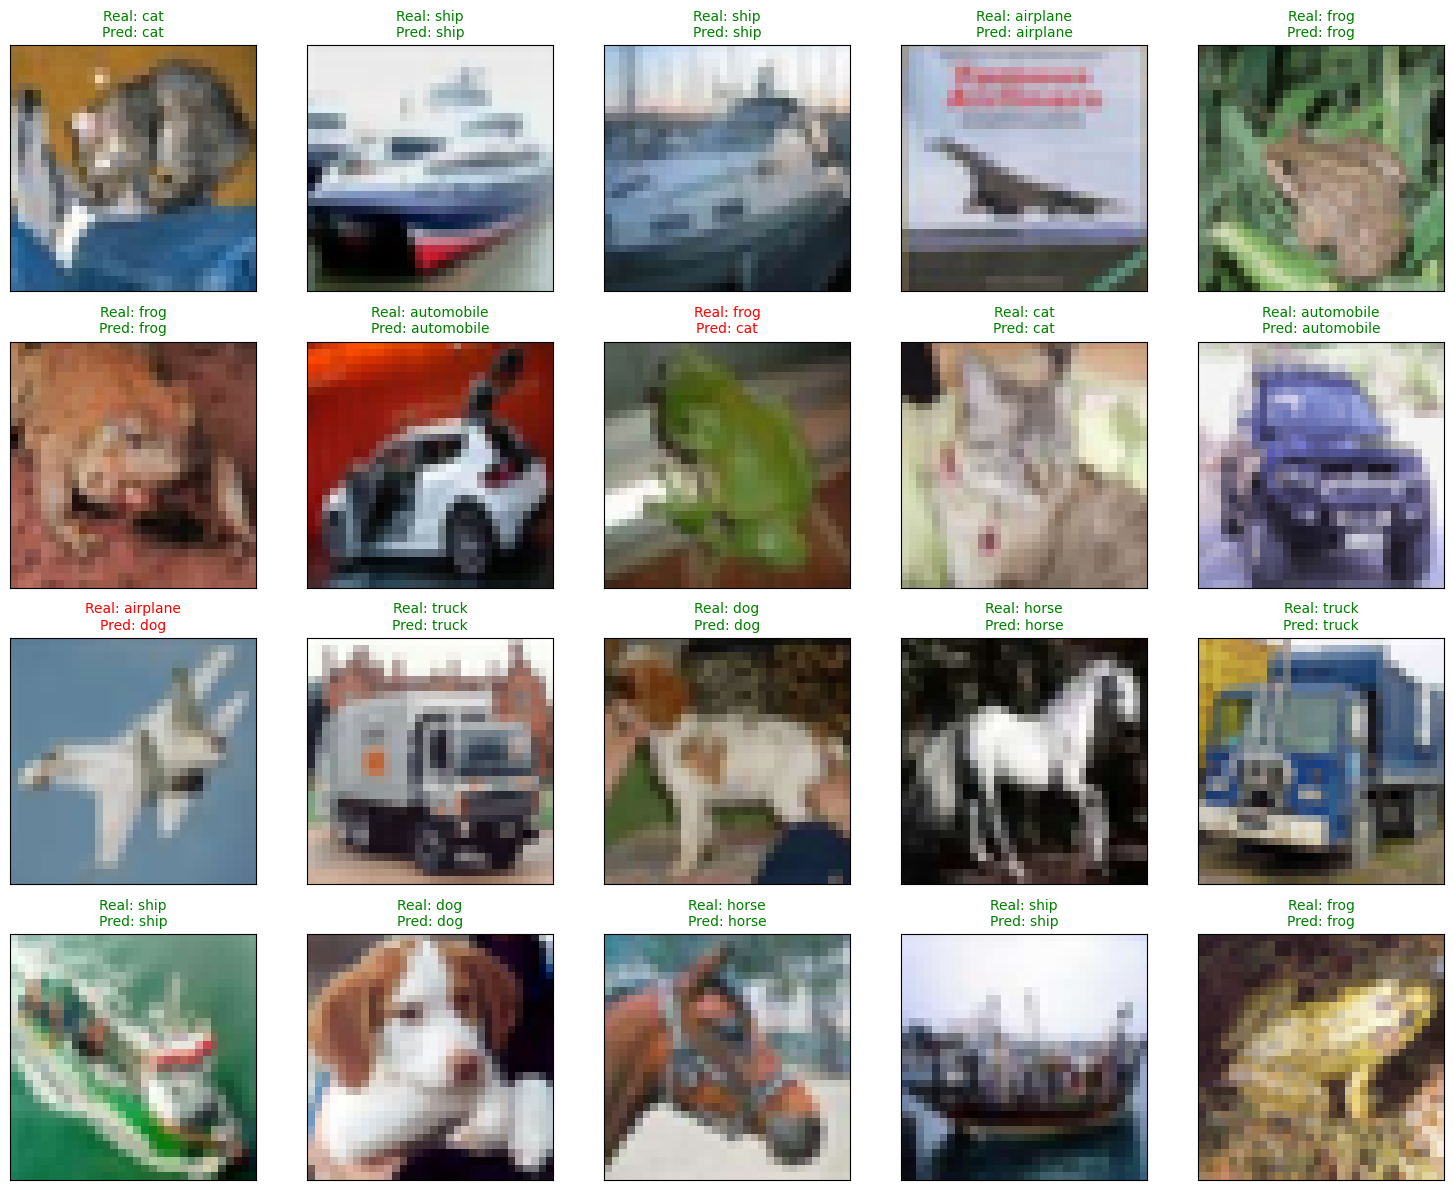

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo le etichette testuali del CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Otteniamo le previsioni per i primi 20 campioni del test set
predictions = model.predict(x_test[:20])

# 3. Creiamo la visualizzazione
plt.figure(figsize=(15, 12))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    # Mostriamo l'immagine
    plt.imshow(x_test[i])
    
    # Calcoliamo l'indice predetto e quello reale
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i][0]
    
    # Colore del testo: verde se corretto, rosso se sbagliato
    color = 'green' if predicted_label == true_label else 'red'
    
    plt.title(f"Real: {class_names[true_label]}\nPred: {class_names[predicted_label]}", 
              color=color, fontsize=10)

plt.tight_layout()
plt.show()